# Enhanced Feature Engineering — Churn Prediction
## HPB Fintech Hackathon 2026

### Goal
Improve on notebook 03's F1 = 0.386 by engineering **10 additional features** from unused data columns.

### New Features (10)
| # | Feature | Source | Rationale |
|---|---------|--------|-----------|
| 1 | `age` | clients | Demographic risk factor |
| 2 | `credit_rating` | clients | Financial health indicator |
| 3 | `has_deposit` | products | Product engagement depth |
| 4 | `digital_txn_ratio` | transactions | Digital engagement signal |
| 5 | `debit_credit_ratio` | transactions | Spending behavior pattern |
| 6 | `balance_volatility` | balances | Financial stability |
| 7 | `txn_amount_std` | transactions | Spending variability |
| 8 | `recency_days` | transactions | Activity recency |
| 9 | `n_complaint_contacts` | contacts | Dissatisfaction signal |
| 10 | `avg_product_age_years` | products | Relationship depth |

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    f1_score, precision_score, recall_score, accuracy_score,
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})

RAW = Path('../data/raw')
PROCESSED = Path('../data/processed')
OUTPUT = Path('../data/output')

CORE_DOMAINS = {'ACCOUNTS', 'LOANS', 'DEPOSITS'}
PLACEHOLDER_DATE = '1/1/2023/'

FEAT_START = pd.Timestamp('2025-04-01')
FEAT_END   = pd.Timestamp('2025-12-31')
REF        = pd.Timestamp('2026-01-01')
CHURN_END  = pd.Timestamp('2026-03-31')

# ── EU-format parsing helpers ──
def parse_eu_date(s):
    return pd.to_datetime(s.str.strip().str.rstrip('/'), format='%d/%m/%Y', errors='coerce')

def parse_eu_datetime(s):
    return pd.to_datetime(
        s.str.strip().str.replace('/ ', ' ', regex=False),
        format='%d/%m/%Y %H:%M:%S', errors='coerce')

def eu_to_float(s):
    return pd.to_numeric(
        s.str.replace('.', '', regex=False).str.replace(',', '.', regex=False),
        errors='coerce')

print('Libraries loaded')

Libraries loaded


## 1. Load & Parse Raw Data

In [18]:
# ── Load all raw datasets ──
clients = pd.read_csv(RAW / 'clients.csv', dtype=str)
clients['age'] = pd.to_numeric(clients['age'], errors='coerce')
clients['first_relationship_date'] = parse_eu_date(clients['first_relationship_date'])

products_raw = pd.read_csv(RAW / 'products.csv', dtype=str)
products_raw.loc[products_raw['closing_date'] == PLACEHOLDER_DATE, 'closing_date'] = np.nan
products_raw['opening_date'] = parse_eu_date(products_raw['opening_date'])
products_raw['closing_date'] = parse_eu_date(products_raw['closing_date'])
products = products_raw.copy()
products_core = products[products['product_domain'].isin(CORE_DOMAINS)].copy()

transactions = pd.read_csv(RAW / 'transactions.csv', dtype=str)
transactions = transactions.loc[:, transactions.columns.notna()]
transactions['date'] = parse_eu_datetime(transactions['txn_datetime'])
transactions['amount'] = eu_to_float(transactions['amount'])

balances = pd.read_csv(RAW / 'balances.csv', dtype=str)
balances['balance'] = eu_to_float(balances['balance'])
balances['valid_from'] = parse_eu_date(balances['valid_from'])

contacts = pd.read_csv(RAW / 'contacts.csv', dtype=str)
contacts['date'] = parse_eu_datetime(contacts['created_at'])

prod_client = products[['product_id', 'client_id']].drop_duplicates()

for name, df in [('Clients', clients), ('Products', products),
                  ('Transactions', transactions), ('Balances', balances),
                  ('Contacts', contacts)]:
    print(f'{name:15s} {df.shape[0]:>10,} rows x {df.shape[1]:>3} cols')

Clients             11,997 rows x  38 cols
Products            58,703 rows x  13 cols
Transactions     1,048,575 rows x  12 cols
Balances           817,933 rows x   6 cols
Contacts            23,605 rows x   6 cols


## 2. Population & Labels (same as notebook 01/03)

In [19]:
# ── At-risk population: ANY active product at REF ──
prods_ref = products[
    (products['opening_date'] <= REF) &
    (products['closing_date'].isna() | (products['closing_date'] > REF))
]
risk_ids = set(prods_ref['client_id'].unique())

# ── Labels: churn = lost all CORE products ──
core_ref = products_core[
    (products_core['opening_date'] <= REF) &
    (products_core['closing_date'].isna() | (products_core['closing_date'] > REF))
]
had_core_ids = set(core_ref['client_id'].unique())

core_end = products_core[
    (products_core['opening_date'] <= CHURN_END) &
    (products_core['closing_date'].isna() | (products_core['closing_date'] > CHURN_END))
]
core_active_end = set(core_end['client_id'].unique())
churned = (risk_ids & had_core_ids) - core_active_end

feat = pd.DataFrame({'client_id': list(risk_ids)})
feat['churned'] = feat['client_id'].isin(churned).astype(int)

n_c = feat['churned'].sum()
print(f'At-risk population: {len(feat):,}')
print(f'  Churned: {n_c:,} ({n_c/len(feat):.1%})')
print(f'  Active:  {len(feat)-n_c:,} ({(len(feat)-n_c)/len(feat):.1%})')

At-risk population: 7,805
  Churned: 131 (1.7%)
  Active:  7,674 (98.3%)


## 3. Original 10 Features (from notebook 01)

In [20]:
# ── 1. tenure_years ──
kl = clients[['client_id', 'first_relationship_date']].copy()
kl['tenure_years'] = (REF - kl['first_relationship_date']).dt.days / 365.25
feat = feat.merge(kl[['client_id', 'tenure_years']], on='client_id', how='left')

# ── 2. n_products ──
n_pr = prods_ref.groupby('client_id').size().reset_index(name='n_products')
feat = feat.merge(n_pr, on='client_id', how='left')

# ── 3. has_loan ──
loan_ids = set(prods_ref[prods_ref['product_domain'] == 'LOANS']['client_id'])
feat['has_loan'] = feat['client_id'].isin(loan_ids).astype(int)

# ── 4. receives_salary ──
feat = feat.merge(
    clients[['client_id', 'receives_salary_at_bank']],
    on='client_id', how='left')
feat['receives_salary'] = (feat['receives_salary_at_bank'] == 'YES').astype(int)
feat.drop(columns=['receives_salary_at_bank'], inplace=True)

# ── Transaction features (5, 6, 7) ──
txn_w = transactions[(transactions['date'] >= FEAT_START) & (transactions['date'] <= FEAT_END)]
txn_c = txn_w.merge(prod_client, on='product_id', how='left')
txn_c = txn_c[txn_c['client_id'].isin(risk_ids)]

txn_agg = txn_c.groupby('client_id').agg(
    n_txn=('amount', 'size'),
    avg_txn_amount=('amount', 'mean'),
    n_months=('date', lambda x: x.dt.to_period('M').nunique())
).reset_index()
txn_agg['avg_txn_per_month'] = txn_agg['n_txn'] / txn_agg['n_months'].clip(lower=1)
feat = feat.merge(
    txn_agg[['client_id', 'avg_txn_per_month', 'avg_txn_amount']],
    on='client_id', how='left')

# Transaction trend (slope of monthly counts)
txn_mc = txn_c.groupby(
    ['client_id', txn_c['date'].dt.to_period('M')]
).size().reset_index(name='n_txn')
txn_mc['mo'] = txn_mc['date'].apply(lambda p: p.year * 12 + p.month)

def slope(grp):
    if len(grp) < 2:
        return 0.0
    x = grp['mo'].values.astype(float)
    y = grp['n_txn'].values.astype(float)
    x = x - x.mean()
    d = (x ** 2).sum()
    return (x * (y - y.mean())).sum() / d if d else 0.0

txn_slopes = txn_mc.groupby('client_id').apply(slope).reset_index(name='txn_trend')
feat = feat.merge(txn_slopes, on='client_id', how='left')

# ── 8. avg_balance ──
bal_w = balances[
    (balances['balance_type'] == 'ACCOUNT_BALANCE') &
    (balances['valid_from'] >= FEAT_START) & (balances['valid_from'] <= FEAT_END)
]
bal_c = bal_w.merge(prod_client, on='product_id', how='left')
bal_c = bal_c[bal_c['client_id'].isin(risk_ids)]

avg_b = bal_c.groupby('client_id')['balance'].mean().reset_index(name='avg_balance')
feat = feat.merge(avg_b, on='client_id', how='left')

# ── 9. balance_trend ──
bal_c_trend = bal_c.copy()
bal_c_trend['mo'] = bal_c_trend['valid_from'].dt.year * 12 + bal_c_trend['valid_from'].dt.month
bal_mo = bal_c_trend.groupby(['client_id', 'mo'])['balance'].median().reset_index(name='n_txn')
bal_slopes = bal_mo.groupby('client_id').apply(slope).reset_index(name='balance_trend')
feat = feat.merge(bal_slopes, on='client_id', how='left')

# ── 10. n_contacts ──
con_w = contacts[(contacts['date'] >= FEAT_START) & (contacts['date'] <= FEAT_END)]
con_w = con_w[con_w['client_id'].isin(risk_ids)]
n_con = con_w.groupby('client_id').size().reset_index(name='n_contacts')
feat = feat.merge(n_con, on='client_id', how='left')

ORIG_FEATURES = ['tenure_years', 'n_products', 'has_loan', 'receives_salary',
                 'avg_txn_per_month', 'avg_txn_amount', 'txn_trend',
                 'avg_balance', 'balance_trend', 'n_contacts']

print(f'Original features built: {len(ORIG_FEATURES)}')
print(f'Feature matrix so far: {feat.shape}')

Original features built: 10
Feature matrix so far: (7805, 12)


## 4. NEW Features (10 additional)

In [21]:
# ═══════════════════════════════════════════════════════════
# NEW FEATURE 1: age
# ═══════════════════════════════════════════════════════════
feat = feat.merge(clients[['client_id', 'age']], on='client_id', how='left')
print(f'1. age — median: {feat["age"].median():.0f}, missing: {feat["age"].isnull().sum()}')

# ═══════════════════════════════════════════════════════════
# NEW FEATURE 2: credit_rating (numeric, lower = better)
# ═══════════════════════════════════════════════════════════
cr = clients[['client_id', 'credit_rating']].copy()
cr['credit_rating'] = pd.to_numeric(cr['credit_rating'], errors='coerce')
feat = feat.merge(cr, on='client_id', how='left')
print(f'2. credit_rating — median: {feat["credit_rating"].median()}, missing: {feat["credit_rating"].isnull().sum()}')

# ═══════════════════════════════════════════════════════════
# NEW FEATURE 3: has_deposit (binary)
# ═══════════════════════════════════════════════════════════
deposit_ids = set(prods_ref[prods_ref['product_domain'] == 'DEPOSITS']['client_id'])
feat['has_deposit'] = feat['client_id'].isin(deposit_ids).astype(int)
print(f'3. has_deposit — {feat["has_deposit"].mean():.1%} have deposits')

# ═══════════════════════════════════════════════════════════
# NEW FEATURE 4: digital_txn_ratio
# Ratio of digital channel transactions (internet + mobile)
# ═══════════════════════════════════════════════════════════
txn_chan = txn_c.copy()
digital_channels = {'Retail internet banking', 'SEPA Instant'}
txn_chan['is_digital'] = txn_chan['channel'].isin(digital_channels).astype(int)
chan_agg = txn_chan.groupby('client_id').agg(
    n_total=('is_digital', 'size'),
    n_digital=('is_digital', 'sum')
).reset_index()
chan_agg['digital_txn_ratio'] = chan_agg['n_digital'] / chan_agg['n_total']
feat = feat.merge(chan_agg[['client_id', 'digital_txn_ratio']], on='client_id', how='left')
print(f'4. digital_txn_ratio — median: {feat["digital_txn_ratio"].median():.3f}')

# ═══════════════════════════════════════════════════════════
# NEW FEATURE 5: debit_credit_ratio
# Ratio of debit (outflow) to credit (inflow) transactions
# ═══════════════════════════════════════════════════════════
txn_dir = txn_c.groupby(['client_id', 'direction']).size().unstack(fill_value=0).reset_index()
if 'D' not in txn_dir.columns:
    txn_dir['D'] = 0
if 'C' not in txn_dir.columns:
    txn_dir['C'] = 0
txn_dir['debit_credit_ratio'] = txn_dir['D'] / (txn_dir['C'] + 1)  # +1 to avoid division by zero
feat = feat.merge(txn_dir[['client_id', 'debit_credit_ratio']], on='client_id', how='left')
print(f'5. debit_credit_ratio — median: {feat["debit_credit_ratio"].median():.3f}')

# ═══════════════════════════════════════════════════════════
# NEW FEATURE 6: balance_volatility
# Std deviation of monthly median balances
# ═══════════════════════════════════════════════════════════
bal_vol = bal_c_trend.groupby(['client_id', 'mo'])['balance'].median().reset_index()
bal_vol_agg = bal_vol.groupby('client_id')['balance'].std().reset_index(name='balance_volatility')
feat = feat.merge(bal_vol_agg, on='client_id', how='left')
print(f'6. balance_volatility — median: {feat["balance_volatility"].median():.1f}')

# ═══════════════════════════════════════════════════════════
# NEW FEATURE 7: txn_amount_std
# Standard deviation of transaction amounts (spending variability)
# ═══════════════════════════════════════════════════════════
txn_std = txn_c.groupby('client_id')['amount'].std().reset_index(name='txn_amount_std')
feat = feat.merge(txn_std, on='client_id', how='left')
print(f'7. txn_amount_std — median: {feat["txn_amount_std"].median():.1f}')

# ═══════════════════════════════════════════════════════════
# NEW FEATURE 8: recency_days
# Days since last transaction before reference date
# ═══════════════════════════════════════════════════════════
last_txn = txn_c.groupby('client_id')['date'].max().reset_index(name='last_txn_date')
last_txn['recency_days'] = (REF - last_txn['last_txn_date']).dt.days
feat = feat.merge(last_txn[['client_id', 'recency_days']], on='client_id', how='left')
print(f'8. recency_days — median: {feat["recency_days"].median():.0f}')

# ═══════════════════════════════════════════════════════════
# NEW FEATURE 9: n_complaint_contacts
# Number of complaint/collection contacts (Prigovor + Naplata)
# ═══════════════════════════════════════════════════════════
complaint_types = {'Prigovor', 'Naplata'}
comp_w = con_w[con_w['case_type'].isin(complaint_types)]
n_comp = comp_w.groupby('client_id').size().reset_index(name='n_complaint_contacts')
feat = feat.merge(n_comp, on='client_id', how='left')
print(f'9. n_complaint_contacts — {(feat["n_complaint_contacts"].fillna(0) > 0).mean():.1%} have complaints')

# ═══════════════════════════════════════════════════════════
# NEW FEATURE 10: avg_product_age_years
# Average age of active products at reference date
# ═══════════════════════════════════════════════════════════
prods_age = prods_ref.copy()
prods_age['product_age_days'] = (REF - prods_age['opening_date']).dt.days
avg_prod_age = prods_age.groupby('client_id')['product_age_days'].mean().reset_index()
avg_prod_age['avg_product_age_years'] = avg_prod_age['product_age_days'] / 365.25
feat = feat.merge(avg_prod_age[['client_id', 'avg_product_age_years']], on='client_id', how='left')
print(f'10. avg_product_age_years — median: {feat["avg_product_age_years"].median():.1f}')

NEW_FEATURES = ['age', 'credit_rating', 'has_deposit', 'digital_txn_ratio',
                'debit_credit_ratio', 'balance_volatility', 'txn_amount_std',
                'recency_days', 'n_complaint_contacts', 'avg_product_age_years']

ALL_FEATURES = ORIG_FEATURES + NEW_FEATURES
print(f'\nTotal features: {len(ALL_FEATURES)} ({len(ORIG_FEATURES)} original + {len(NEW_FEATURES)} new)')
print(f'Feature matrix: {feat.shape}')

1. age — median: 61, missing: 0
2. credit_rating — median: 3.0, missing: 5576
3. has_deposit — 4.3% have deposits
4. digital_txn_ratio — median: 0.000
5. debit_credit_ratio — median: 4.167
6. balance_volatility — median: 178.3
7. txn_amount_std — median: 138.5
8. recency_days — median: 12
9. n_complaint_contacts — 0.1% have complaints
10. avg_product_age_years — median: 4.6

Total features: 20 (10 original + 10 new)
Feature matrix: (7805, 22)


## 5. Imputation & Cleaning

In [22]:
# ── Imputation ──
# Behavioral features: NaN = no activity → 0
behavioral_cols = ['avg_txn_per_month', 'avg_txn_amount', 'txn_trend',
                   'avg_balance', 'balance_trend', 'n_contacts',
                   'digital_txn_ratio', 'debit_credit_ratio',
                   'balance_volatility', 'txn_amount_std',
                   'n_complaint_contacts']

for col in behavioral_cols:
    n_fill = feat[col].isnull().sum()
    feat[col] = feat[col].fillna(0)
    if n_fill > 0:
        print(f'  {col}: filled {n_fill:,} NaN → 0')

# Recency: NaN = no transactions → fill with max (worst recency)
n_fill = feat['recency_days'].isnull().sum()
max_recency = (REF - FEAT_START).days  # max possible = entire feature window
feat['recency_days'] = feat['recency_days'].fillna(max_recency)
print(f'  recency_days: filled {n_fill:,} NaN → {max_recency} (max window)')

# Demographic: fill with median
for col in ['tenure_years', 'age', 'credit_rating', 'avg_product_age_years']:
    n_fill = feat[col].isnull().sum()
    if n_fill > 0:
        med = feat[col].median()
        feat[col] = feat[col].fillna(med)
        print(f'  {col}: filled {n_fill:,} NaN → median ({med:.1f})')

print(f'\nRemaining NaN: {feat[ALL_FEATURES].isnull().sum().sum()}')
print(f'\nFeature statistics:')
print(feat[ALL_FEATURES].describe().round(3).to_string())

  avg_txn_per_month: filled 2,558 NaN → 0
  avg_txn_amount: filled 2,558 NaN → 0
  txn_trend: filled 2,558 NaN → 0
  avg_balance: filled 4,038 NaN → 0
  balance_trend: filled 4,038 NaN → 0
  n_contacts: filled 6,918 NaN → 0
  digital_txn_ratio: filled 2,558 NaN → 0
  debit_credit_ratio: filled 2,558 NaN → 0
  balance_volatility: filled 4,063 NaN → 0
  txn_amount_std: filled 2,744 NaN → 0
  n_complaint_contacts: filled 7,799 NaN → 0
  recency_days: filled 2,558 NaN → 275 (max window)
  credit_rating: filled 5,576 NaN → median (3.0)

Remaining NaN: 0

Feature statistics:
       tenure_years  n_products  has_loan  receives_salary  avg_txn_per_month  avg_txn_amount  txn_trend  avg_balance  balance_trend  n_contacts       age  credit_rating  has_deposit  digital_txn_ratio  debit_credit_ratio  balance_volatility  txn_amount_std  recency_days  n_complaint_contacts  avg_product_age_years
count      7805.000    7805.000  7805.000         7805.000           7805.000        7805.000   7805.000   

## 6. New Feature Distributions & Correlation

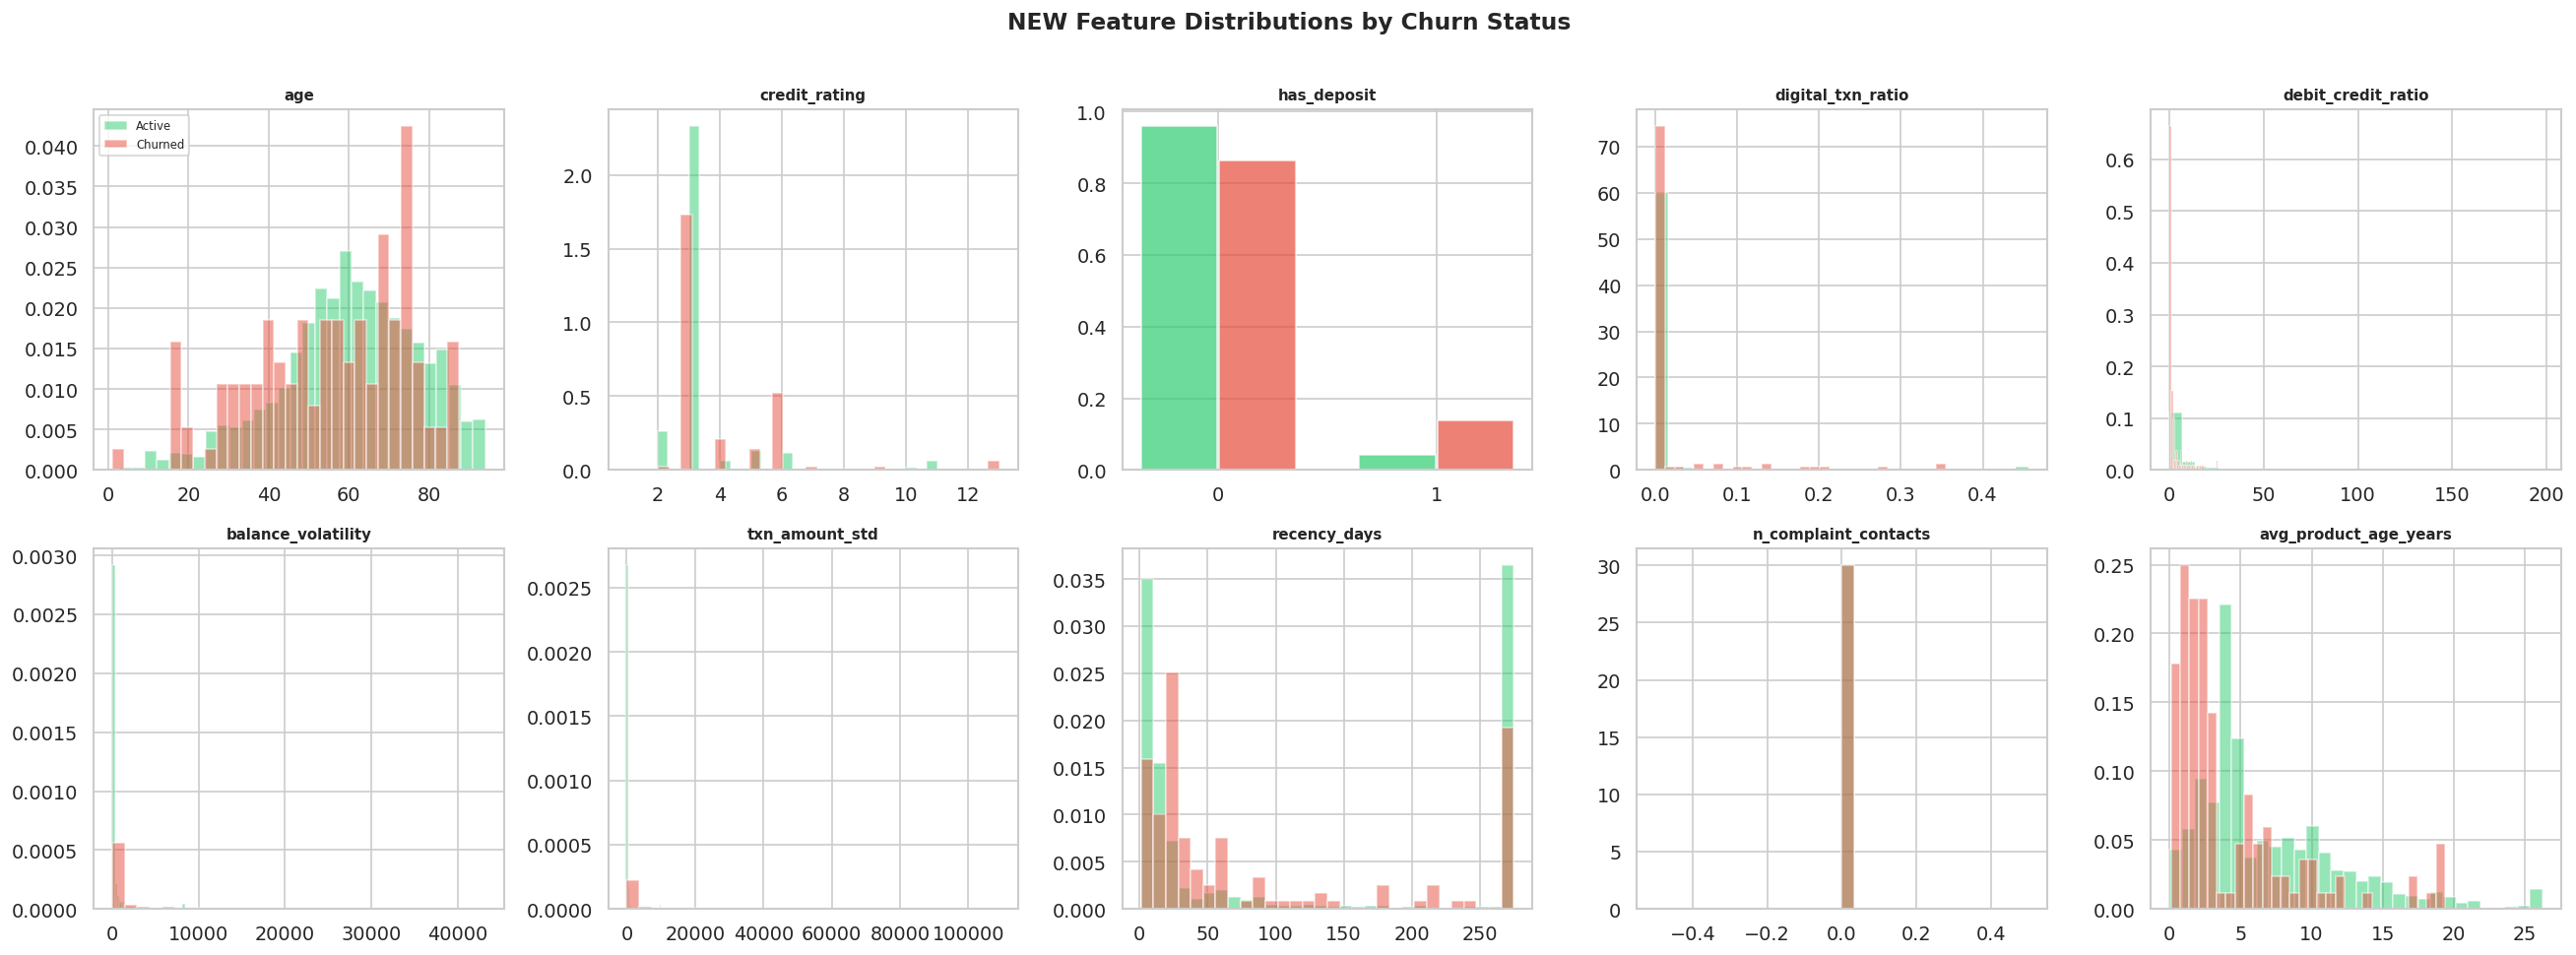

Correlation with churn target (all 20 features):
tenure_years             0.1320
avg_txn_amount           0.1243
txn_amount_std           0.1236
receives_salary          0.0723
avg_product_age_years    0.0657
balance_volatility       0.0633
has_deposit              0.0607
avg_balance              0.0584
age                      0.0334
debit_credit_ratio       0.0328
credit_rating            0.0213
recency_days             0.0213
avg_txn_per_month        0.0208
balance_trend            0.0199
n_products               0.0117
n_contacts               0.0061
txn_trend                0.0053
n_complaint_contacts     0.0032
has_loan                 0.0028
digital_txn_ratio        0.0001


In [23]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.flatten()

binary_features = {'has_deposit'}

for i, col in enumerate(NEW_FEATURES):
    ax = axes[i]
    for val, label, color in [(0, 'Active', '#2ecc71'), (1, 'Churned', '#e74c3c')]:
        subset = feat.loc[feat['churned'] == val, col].dropna()
        if col in binary_features:
            vals = [0, 1]
            counts = subset.value_counts(normalize=True).reindex(vals, fill_value=0)
            offset = -0.18 if val == 0 else 0.18
            ax.bar([v + offset for v in vals], counts.values,
                   alpha=0.7, color=color, width=0.35, label=label)
            ax.set_xticks([0, 1])
        else:
            clipped = subset.clip(upper=subset.quantile(0.99))
            ax.hist(clipped, bins=30, alpha=0.5, color=color, label=label, density=True)
    ax.set_title(col, fontweight='bold', fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

plt.suptitle('NEW Feature Distributions by Churn Status', fontweight='bold', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Correlation with target
target_corr = feat[ALL_FEATURES].corrwith(feat['churned']).abs().sort_values(ascending=False)
print('Correlation with churn target (all 20 features):')
print(target_corr.round(4).to_string())

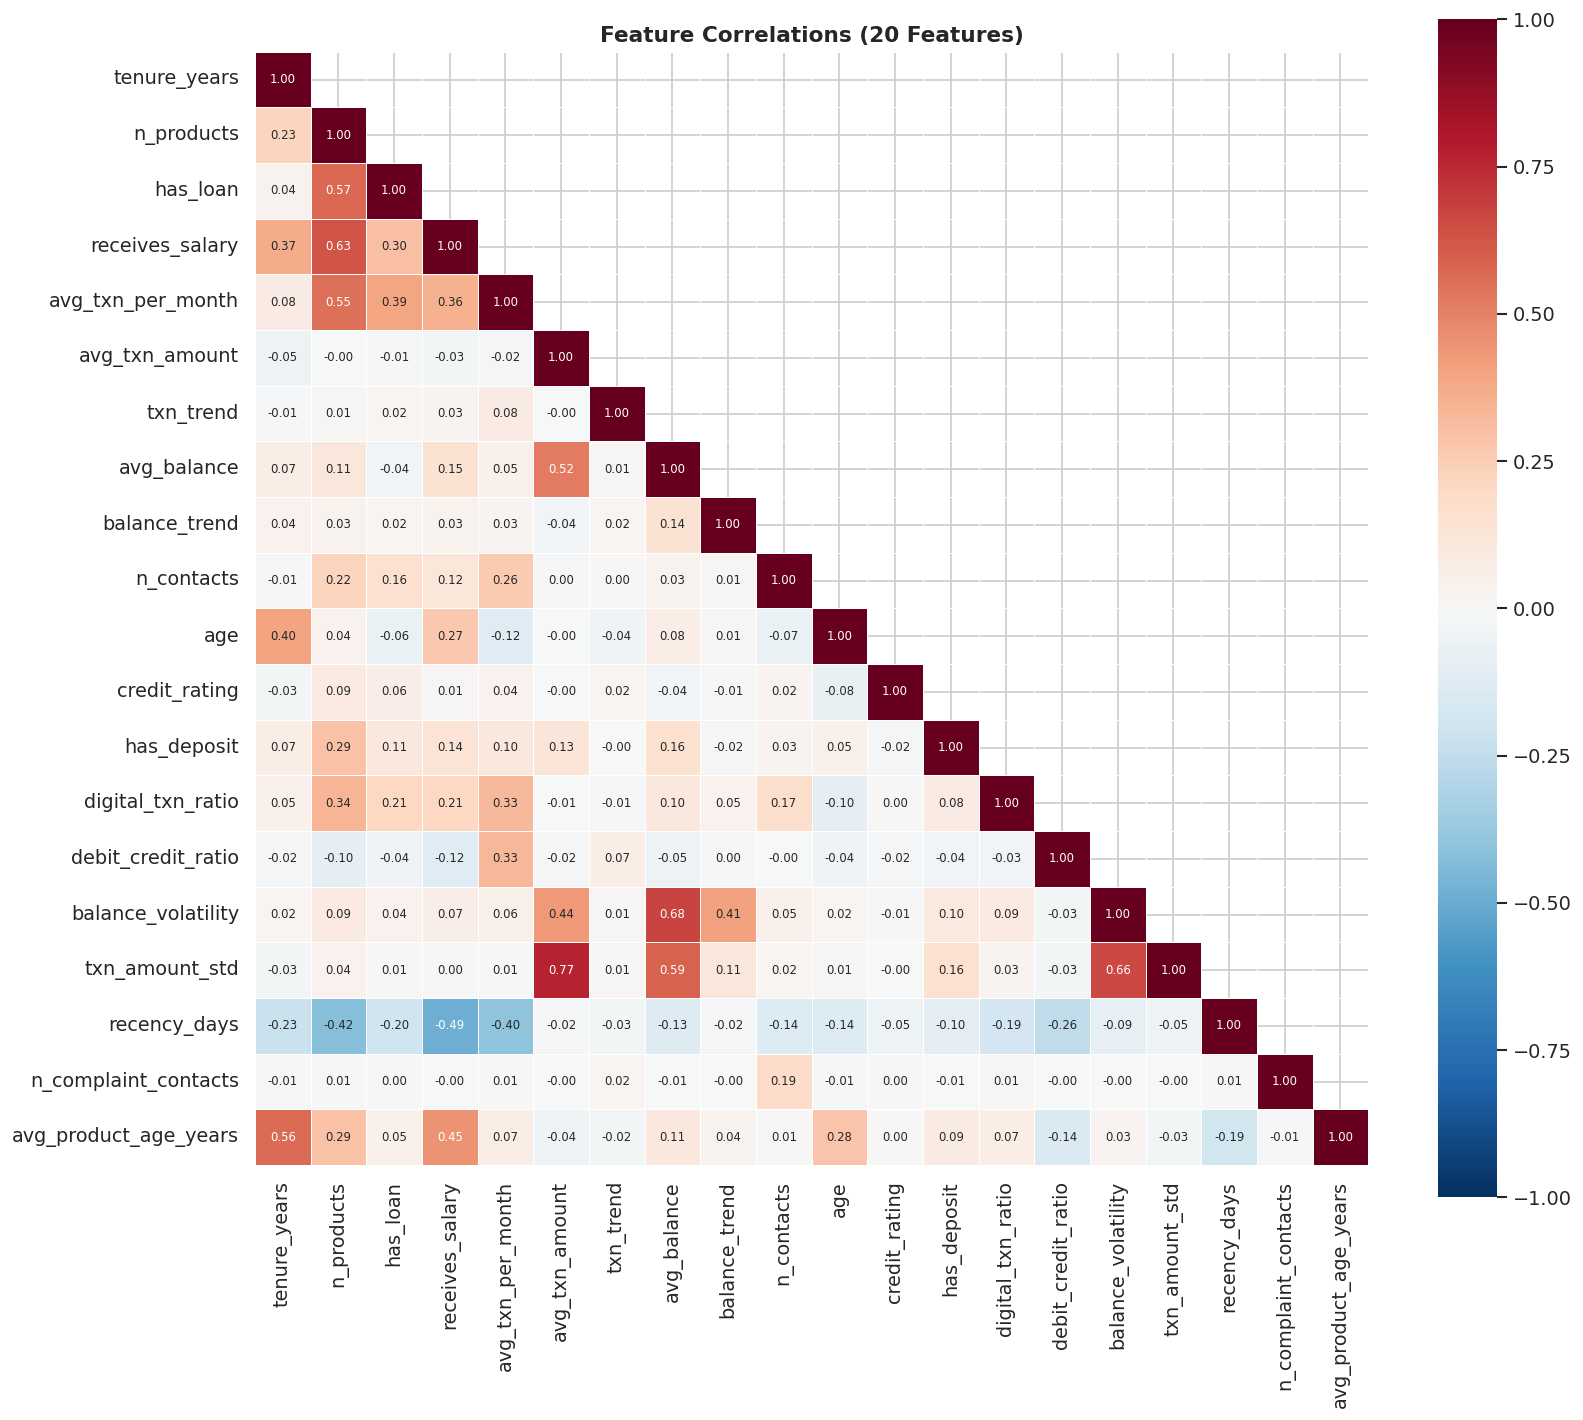

No feature pairs with |r| > 0.8


In [24]:
# Full correlation heatmap
fig, ax = plt.subplots(figsize=(14, 12))
corr = feat[ALL_FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, square=True, linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Feature Correlations (20 Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
high_corr = []
cols = ALL_FEATURES
for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        r = abs(corr.iloc[i, j])
        if r > 0.8:
            high_corr.append((cols[i], cols[j], r))

if high_corr:
    print('Highly correlated pairs (|r| > 0.8):')
    for f1, f2, r in sorted(high_corr, key=lambda x: -x[2]):
        print(f'  {f1} <-> {f2}: {r:.3f}')
else:
    print('No feature pairs with |r| > 0.8')

## 7. Model Training — LightGBM with Optuna

In [25]:
META_COLS = ['client_id', 'churned']
TARGET = 'churned'

X = feat[ALL_FEATURES]
y = feat[TARGET]

print(f'Dataset: {len(feat):,} samples, {len(ALL_FEATURES)} features')
print(f'Churn rate: {y.mean():.1%} ({y.sum()} churned / {len(y)} total)')

# ── Stratified Train/Test Split (80/20) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f'Train: {len(X_train):,} samples, {y_train.sum()} churned ({y_train.mean():.1%})')
print(f'Test:  {len(X_test):,} samples, {y_test.sum()} churned ({y_test.mean():.1%})')

# ── SMOTE oversampling on training data only ──
smote = SMOTE(random_state=42, sampling_strategy=0.3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'\nAfter SMOTE: {len(X_train_sm):,} samples, {y_train_sm.sum()} churned ({y_train_sm.mean():.1%})')

Dataset: 7,805 samples, 20 features
Churn rate: 1.7% (131 churned / 7805 total)
Train: 6,244 samples, 105 churned (1.7%)
Test:  1,561 samples, 26 churned (1.7%)

After SMOTE: 7,980 samples, 1841 churned (23.1%)


In [26]:
# ── Optuna Hyperparameter Tuning (150 trials for better search) ──
def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'binary_logloss',
        'boosting_type': 'gbdt',
        'n_estimators': 500,
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 8, 128),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 80),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 20.0),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'random_state': 42,
        'verbose': -1,
        'n_jobs': -1,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    f1_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        sm = SMOTE(random_state=42, sampling_strategy=0.3)
        X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

        m = lgb.LGBMClassifier(**params)
        m.fit(X_tr_sm, y_tr_sm,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])

        proba = m.predict_proba(X_val)[:, 1]
        best_f1 = 0
        for t in np.arange(0.05, 0.95, 0.02):
            f1 = f1_score(y_val, (proba >= t).astype(int), zero_division=0)
            best_f1 = max(best_f1, f1)
        f1_scores.append(best_f1)

    return np.mean(f1_scores)

print('Running Optuna hyperparameter search (150 trials)...')
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f'\nBest CV F1: {study.best_value:.4f}')
print(f'Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

Running Optuna hyperparameter search (150 trials)...


Best trial: 148. Best value: 0.482081: 100%|██████████| 150/150 [06:59<00:00,  2.80s/it]


Best CV F1: 0.4821
Best params:
  learning_rate: 0.0606
  max_depth: 4
  num_leaves: 97
  min_child_samples: 68
  subsample: 0.7706
  colsample_bytree: 0.5158
  reg_alpha: 0.6842
  reg_lambda: 8.0402
  scale_pos_weight: 3.4632
  min_split_gain: 0.9615


In [27]:
# ── Train Final Model ──
best_params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    **study.best_params,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1,
}

model = lgb.LGBMClassifier(**best_params)
model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)

print(f'Best iteration: {model.best_iteration_}')
y_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)
print(f'Test ROC AUC: {auc:.4f}')
print(f'Test Average Precision (PR AUC): {ap:.4f}')

# ── 5-Fold CV (for robust estimate) ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_probas = np.zeros(len(X))
for train_idx, val_idx in cv.split(X, y):
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    sm = SMOTE(random_state=42, sampling_strategy=0.3)
    X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

    m = lgb.LGBMClassifier(**{**best_params, 'n_estimators': model.best_iteration_})
    m.fit(X_tr_sm, y_tr_sm,
          eval_set=[(X_val, y_val)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)])
    cv_probas[val_idx] = m.predict_proba(X_val)[:, 1]

cv_auc = roc_auc_score(y, cv_probas)
cv_ap = average_precision_score(y, cv_probas)
print(f'\n5-Fold CV (with SMOTE) — ROC AUC: {cv_auc:.4f}, PR AUC: {cv_ap:.4f}')

# ── Calibrate Probabilities ──
cal_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42, sampling_strategy=0.3)),
    ('lgb', lgb.LGBMClassifier(**{**best_params, 'n_estimators': model.best_iteration_})),
])
cal_model = CalibratedClassifierCV(cal_pipe, cv=5, method='sigmoid')
cal_model.fit(X, y)
cal_proba_test = cal_model.predict_proba(X_test)[:, 1]
cal_auc = roc_auc_score(y_test, cal_proba_test)
print(f'Calibrated model — Test ROC AUC: {cal_auc:.4f}')

Best iteration: 331
Test ROC AUC: 0.9415
Test Average Precision (PR AUC): 0.3672

5-Fold CV (with SMOTE) — ROC AUC: 0.9373, PR AUC: 0.3496
Calibrated model — Test ROC AUC: 0.9902


## 8. Threshold Optimization & Evaluation

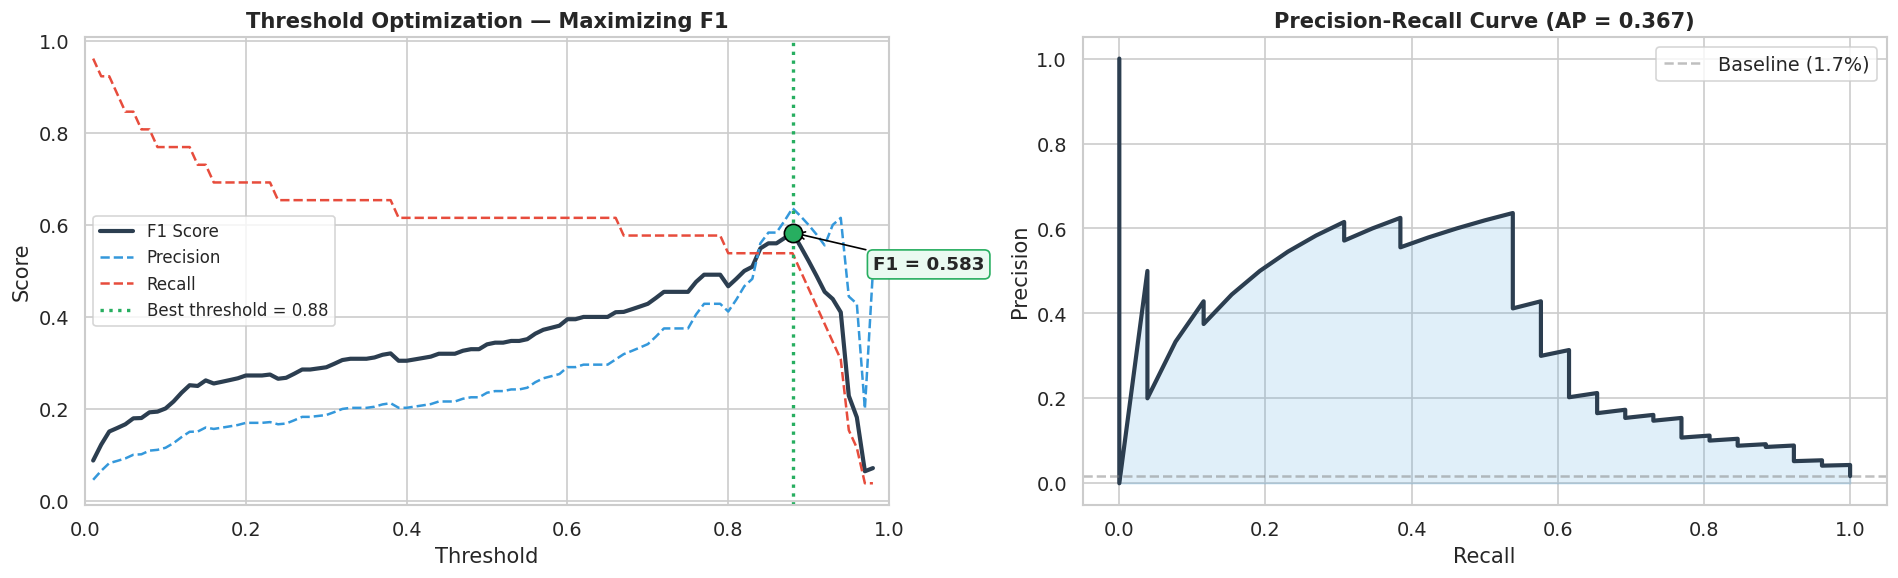

Optimal threshold: 0.88
F1: 0.5833  |  Precision: 0.6364  |  Recall: 0.5385

>>> Improvement over notebook 03: F1 0.5833 vs 0.3860


In [28]:
# ── Threshold Optimization ──
thresholds = np.arange(0.01, 0.99, 0.01)
f1s, precs, recs = [], [], []
for t in thresholds:
    yp = (y_proba >= t).astype(int)
    f1s.append(f1_score(y_test, yp, zero_division=0))
    precs.append(precision_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp, zero_division=0))

best_idx = np.argmax(f1s)
best_t = thresholds[best_idx]
best_f1 = f1s[best_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.plot(thresholds, f1s, color='#2c3e50', lw=2.5, label='F1 Score')
ax.plot(thresholds, precs, color='#3498db', lw=1.5, ls='--', label='Precision')
ax.plot(thresholds, recs, color='#e74c3c', lw=1.5, ls='--', label='Recall')
ax.axvline(best_t, color='#27ae60', lw=2, ls=':', label=f'Best threshold = {best_t:.2f}')
ax.scatter([best_t], [best_f1], color='#27ae60', s=120, zorder=5, edgecolors='black')
ax.annotate(f'F1 = {best_f1:.3f}', xy=(best_t, best_f1),
            xytext=(best_t + 0.1, best_f1 - 0.08), fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.3', fc='#eafaf1', ec='#27ae60'))
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimization — Maximizing F1', fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1)

precision_pr, recall_pr, _ = precision_recall_curve(y_test, y_proba)
ax2 = axes[1]
ax2.plot(recall_pr, precision_pr, color='#2c3e50', lw=2.5)
ax2.fill_between(recall_pr, precision_pr, alpha=0.15, color='#3498db')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title(f'Precision-Recall Curve (AP = {ap:.3f})', fontweight='bold')
ax2.axhline(y_test.mean(), color='gray', ls='--', alpha=0.5, label=f'Baseline ({y_test.mean():.1%})')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Optimal threshold: {best_t:.2f}')
print(f'F1: {best_f1:.4f}  |  Precision: {precs[best_idx]:.4f}  |  Recall: {recs[best_idx]:.4f}')
print(f'\n>>> Improvement over notebook 03: F1 {best_f1:.4f} vs 0.3860')

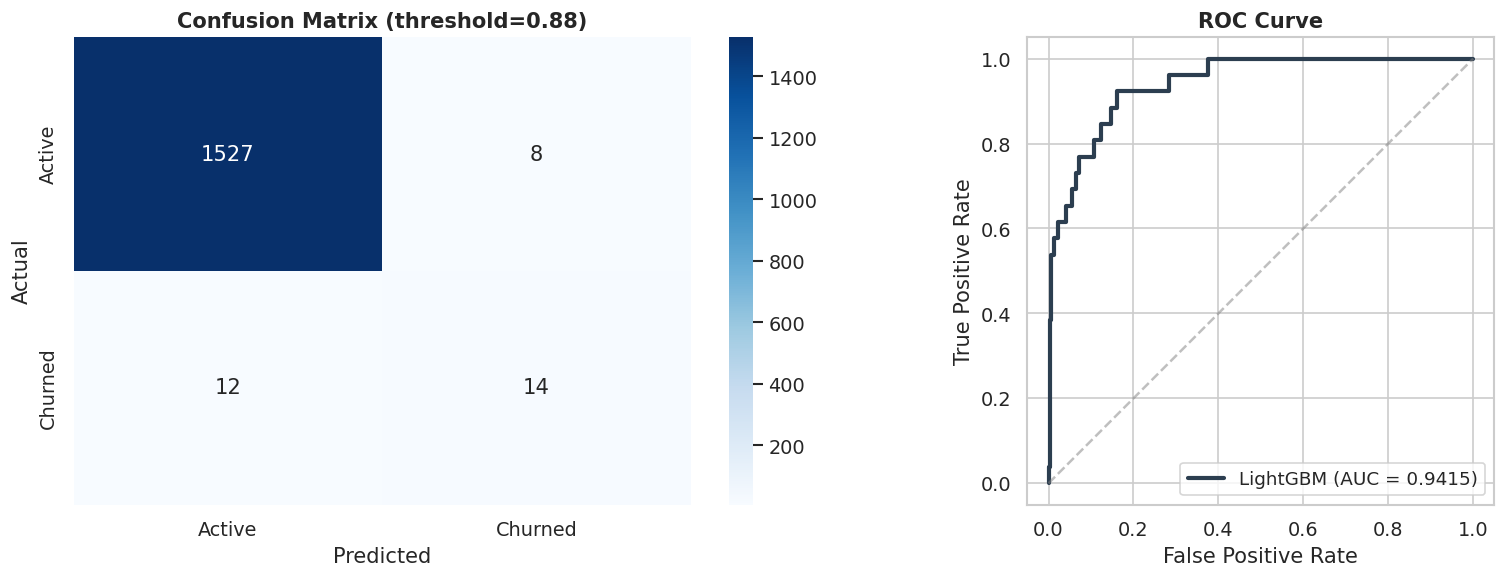

              precision    recall  f1-score   support

      Active       0.99      0.99      0.99      1535
     Churned       0.64      0.54      0.58        26

    accuracy                           0.99      1561
   macro avg       0.81      0.77      0.79      1561
weighted avg       0.99      0.99      0.99      1561



In [29]:
# ── Confusion Matrix & ROC ──
y_pred = (y_proba >= best_t).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title(f'Confusion Matrix (threshold={best_t:.2f})', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2c3e50', lw=2.5, label=f'LightGBM (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', ls='--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))

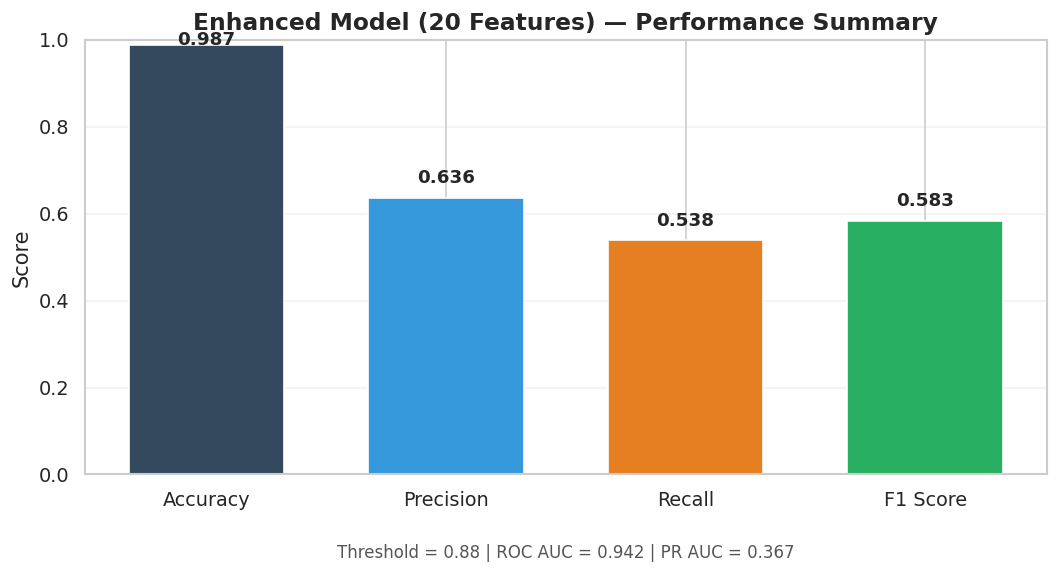

Accuracy     0.9872
Precision    0.6364
Recall       0.5385
F1 Score     0.5833

=== COMPARISON ===
Notebook 03 (10 features): F1 = 0.3860
Notebook 04 (20 features): F1 = 0.5833
Improvement: 0.1973 (+51.1%)


In [30]:
# ── Performance Summary (with comparison to notebook 03) ──
metric_values = pd.Series({
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall': recall_score(y_test, y_pred, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, zero_division=0),
})

fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['#34495e', '#3498db', '#e67e22', '#27ae60']
bars = ax.bar(metric_values.index, metric_values.values, color=bar_colors, width=0.65)

ax.set_ylim(0, 1)
ax.set_ylabel('Score')
ax.set_title('Enhanced Model (20 Features) — Performance Summary', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.25)
ax.set_axisbelow(True)

for bar, value in zip(bars, metric_values.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        min(value + 0.025, 0.98),
        f'{value:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

summary_text = f'Threshold = {best_t:.2f} | ROC AUC = {auc:.3f} | PR AUC = {ap:.3f}'
ax.text(0.5, -0.16, summary_text, transform=ax.transAxes,
        ha='center', va='top', fontsize=10, color='#555555')

plt.tight_layout()
plt.show()

print(metric_values.round(4).to_string())
print(f'\n=== COMPARISON ===')
print(f'Notebook 03 (10 features): F1 = 0.3860')
print(f'Notebook 04 (20 features): F1 = {best_f1:.4f}')
print(f'Improvement: {(best_f1 - 0.3860):.4f} ({(best_f1 - 0.3860)/0.3860*100:+.1f}%)')

## 9. SHAP Feature Importance

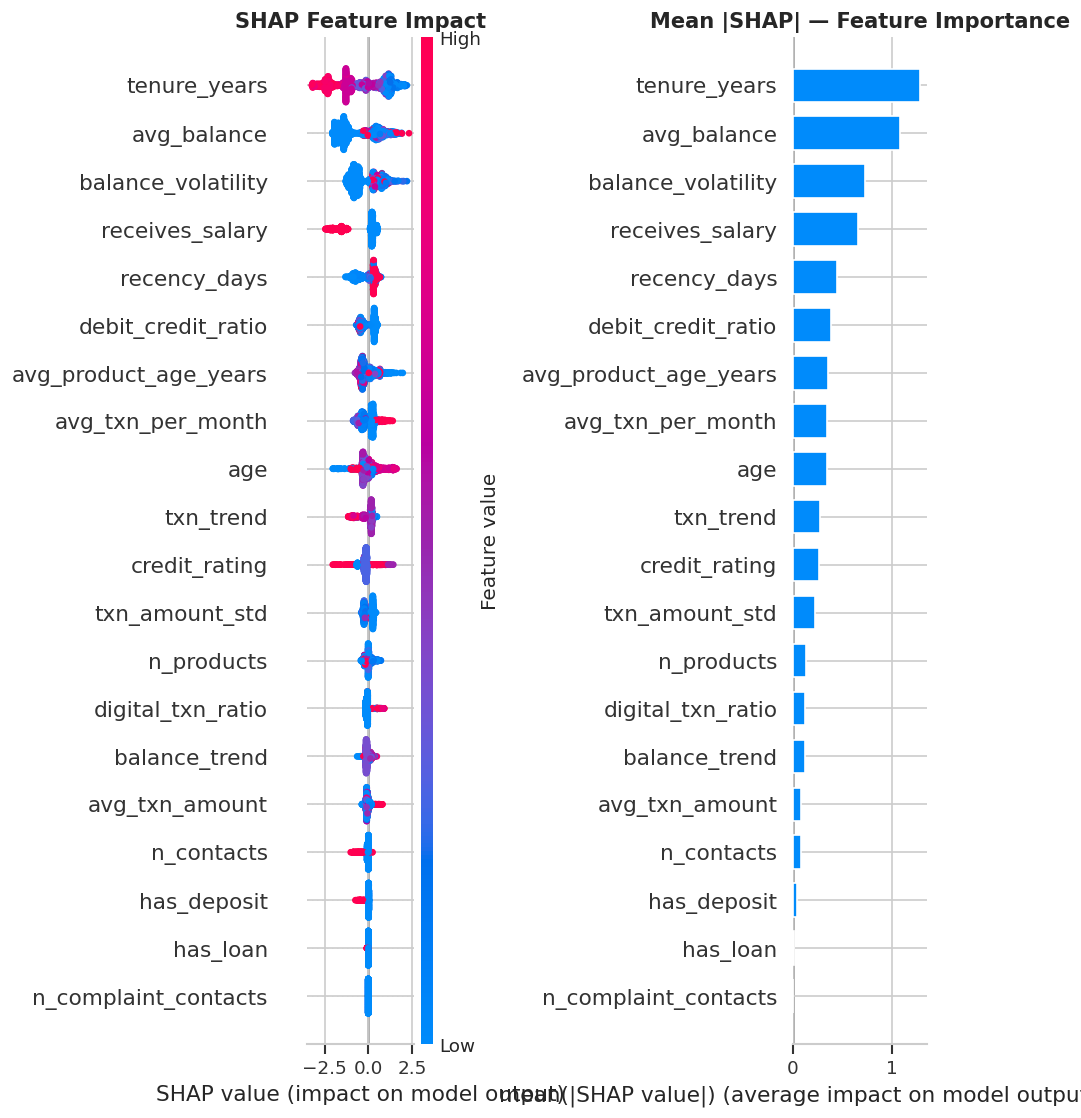

LightGBM feature importance (gain):
              feature  importance is_new
          avg_balance         320   orig
                  age         318    NEW
         tenure_years         311   orig
        credit_rating         293    NEW
avg_product_age_years         281    NEW
         recency_days         184    NEW
   balance_volatility         183    NEW
    avg_txn_per_month         161   orig
        balance_trend         141   orig
            txn_trend         134   orig
           n_products         120   orig
       avg_txn_amount         118   orig
           n_contacts         106   orig
   debit_credit_ratio          93    NEW
       txn_amount_std          82    NEW
    digital_txn_ratio          69    NEW
      receives_salary          37   orig
          has_deposit          25    NEW
             has_loan           3   orig
 n_complaint_contacts           0    NEW


In [31]:
# ── SHAP Feature Importance ──
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

if isinstance(shap_values, list):
    sv = shap_values[1]
else:
    sv = shap_values

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plt.sca(axes[0])
shap.summary_plot(sv, X_test, feature_names=ALL_FEATURES, show=False, max_display=20)
axes[0].set_title('SHAP Feature Impact', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(sv, X_test, feature_names=ALL_FEATURES, plot_type='bar',
                  show=False, max_display=20)
axes[1].set_title('Mean |SHAP| — Feature Importance', fontweight='bold')

plt.tight_layout()
plt.show()

fi = pd.DataFrame({
    'feature': ALL_FEATURES,
    'importance': model.feature_importances_,
    'is_new': ['NEW' if f in NEW_FEATURES else 'orig' for f in ALL_FEATURES]
}).sort_values('importance', ascending=False)
print('LightGBM feature importance (gain):')
print(fi.to_string(index=False))

## 10. Updated Risk Scores

Raw probability range: [0.0000, 0.9863]
Scaled risk score range: [0.0, 1.0]
Scaled threshold: 0.892 (raw: 0.880)


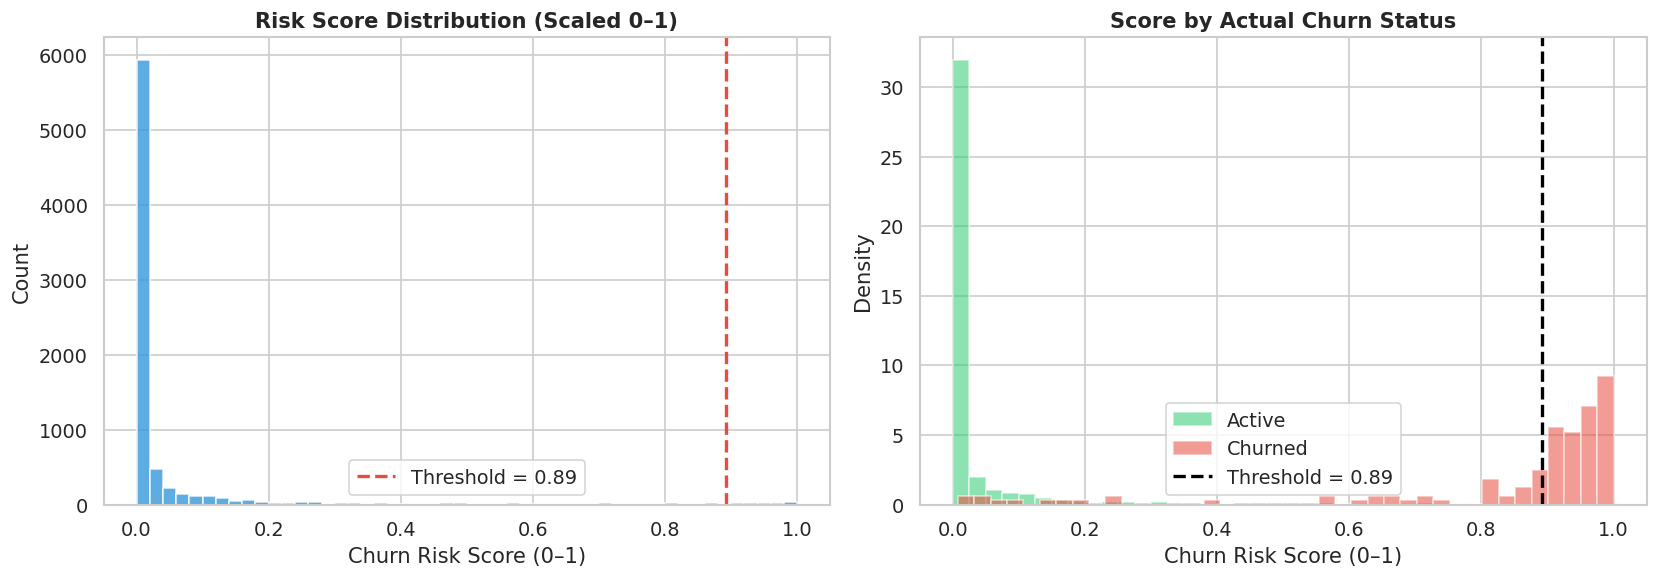

Saved: ../data/output/churn_risk_scores_v2.csv
  High risk: 117 (1.5%)
  Low risk:  7,688 (98.5%)

Top 10 highest-risk customers:


,client_id,churn_risk_score,predicted_churn
0,CQ98L51OGUZB,1.000000,1
1,2RC83NTCGS0S,0.999486,1
2,DIVA3JGEV609,0.998934,1
3,EW0ZRV4SUNUH,0.998115,1
4,YL28BOCXW2YD,0.997138,1
5,M8MT29KKWDMV,0.996057,1
6,EI8Z4SEHJV17,0.995912,1
7,04FTCRKHT3AU,0.994939,1
8,3HHY826MUWJY,0.994688,1
9,TTKN1OC8K1J0,0.994473,1


In [32]:
# ── Risk Scores (scaled 0–1) ──
raw_proba = model.predict_proba(X)[:, 1]

p_min, p_max = raw_proba.min(), raw_proba.max()
risk_scaled = (raw_proba - p_min) / (p_max - p_min)
print(f'Raw probability range: [{p_min:.4f}, {p_max:.4f}]')
print(f'Scaled risk score range: [0.0, 1.0]')

scaled_threshold = (best_t - p_min) / (p_max - p_min)
scaled_threshold = np.clip(scaled_threshold, 0.0, 1.0)
print(f'Scaled threshold: {scaled_threshold:.3f} (raw: {best_t:.3f})')

risk = feat[['client_id']].copy()
risk['churn_risk_score'] = risk_scaled
risk['predicted_churn'] = (risk_scaled >= scaled_threshold).astype(int)
risk = risk.sort_values('churn_risk_score', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(risk['churn_risk_score'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(scaled_threshold, color='#e74c3c', lw=2, ls='--',
                label=f'Threshold = {scaled_threshold:.2f}')
axes[0].set_xlabel('Churn Risk Score (0–1)')
axes[0].set_ylabel('Count')
axes[0].set_title('Risk Score Distribution (Scaled 0–1)', fontweight='bold')
axes[0].legend()

for val, label, color in [(0, 'Active', '#2ecc71'), (1, 'Churned', '#e74c3c')]:
    subset = risk_scaled[y == val]
    axes[1].hist(subset, bins=40, alpha=0.55, color=color, label=label, density=True)
axes[1].axvline(scaled_threshold, color='black', lw=2, ls='--',
                label=f'Threshold = {scaled_threshold:.2f}')
axes[1].set_xlabel('Churn Risk Score (0–1)')
axes[1].set_ylabel('Density')
axes[1].set_title('Score by Actual Churn Status', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

risk_path = OUTPUT / 'churn_risk_scores_v2.csv'
risk.to_csv(risk_path, index=False)

n_high = (risk['predicted_churn'] == 1).sum()
n_low = len(risk) - n_high
print(f'Saved: {risk_path}')
print(f'  High risk: {n_high:,} ({n_high/len(risk):.1%})')
print(f'  Low risk:  {n_low:,} ({n_low/len(risk):.1%})')
print(f'\nTop 10 highest-risk customers:')
risk.head(10)